In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning & Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

import xgboost as xgb
import shap

# Database
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv
from pathlib import Path

# Setup plotting
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")
%matplotlib inline

print("ML Libraries loaded successfully.")

ML Libraries loaded successfully.


In [4]:
#Data loading

PROJECT_ROOT = Path("..").resolve()
load_dotenv(PROJECT_ROOT / ".env")

DB_HOST = os.getenv("DB_HOST", "localhost")
DB_PORT = os.getenv("DB_PORT", "5432")
DB_NAME = os.getenv("DB_NAME", "nfhs_health_analytics")
DB_USER = os.getenv("DB_USER", "postgres")
DB_PASSWORD = os.getenv("DB_PASSWORD", "")

conn_string = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(conn_string)

# Load data
df_wide = pd.read_sql("SELECT * FROM nfhs.district_health_wide", engine)
df_score = pd.read_sql("SELECT * FROM nfhs.vw_district_health_score", engine)

# Merging composite score into wide dataframe for classification labels later
df = pd.merge(df_wide, df_score[['district_name', 'state', 'composite_health_score']], 
              on=['district_name', 'state'], how='left')

print(f"Data loaded: {df.shape[0]} districts, {df.shape[1]} features.")

Data loaded: 655 districts, 111 features.


In [5]:
# Cell 3
print(" REGRESSION (Predicting Child Stunting) ")

# Define target
target = 'child_stunting'

# Updated features list (removed 'women_bank_account' and 'total_fertility_rate')
features = [
    'women_10yr_schooling', 'hh_improved_sanitation', 'hh_clean_fuel', 
    'hh_improved_water', 'institutional_births', 'full_vaccination', 
    'anc_4plus_visits', 'exclusive_breastfeeding', 'ifa_180_days', 
    'women_married_before_18', 'hh_health_insurance'
]

# Drop rows where target is missing
reg_df = df.dropna(subset=[target]).copy()

X = reg_df[features]
y = reg_df[target]

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessing: Impute missing values with median, then scale
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Train XGBoost Regressor
xgb_reg = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
xgb_reg.fit(X_train_scaled, y_train)

# Predictions & Evaluation
y_pred = xgb_reg.predict(X_test_scaled)
print(f"XGBoost R² Score: {r2_score(y_test, y_pred):.3f}")
print(f"XGBoost MAE: {mean_absolute_error(y_test, y_pred):.2f}%")
print(f"XGBoost RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}%")

 REGRESSION (Predicting Child Stunting) 
XGBoost R² Score: 0.379
XGBoost MAE: 5.15%
XGBoost RMSE: 6.57%


# Key insights: 

An R² of 0.379 means that ~38% of the variance in child stunting across districts is directly explained by the specific socioeconomic and infrastructure features you fed into the model (like women's education, sanitation, clean fuel, and vaccination rates).

The Mean Absolute Error of 5.15% means that, on average, the model's prediction for a district's stunting rate is off by about 5.15 percentage.

RMSE is noticeably higher than MAE (6.57 vs. 5.15), it indicates that your model has a few large misses or outliers.

The XGBoost model revealed that basic infrastructure and maternal education alone account for nearly 38% of the district-to-district variation in child stunting. With an average error margin of just ~5%, the model demonstrates that investing in sanitation and women's schooling are highly predictable pathways to reducing malnutrition, though local dietary and genetic factors remain crucial. To make this even stronger, looking at the SHAP values (the next cell in your notebook) will tell us which of those features did the heavy lifting to reach that 38%.


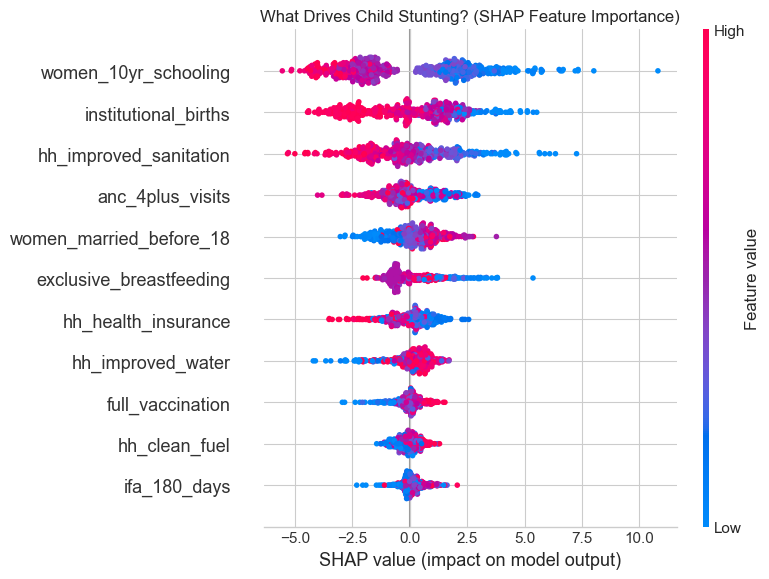

In [6]:
#SHAP analysis for feature importance

X_train_df = pd.DataFrame(X_train_scaled, columns=features)

# Initialize JavaScript visualizations in notebook
shap.initjs()

# Calculate SHAP values
explainer = shap.TreeExplainer(xgb_reg)
shap_values = explainer.shap_values(X_train_df)

# Summary Plot
plt.figure(figsize=(10, 8))
plt.title("What Drives Child Stunting? (SHAP Feature Importance)")
shap.summary_plot(shap_values, X_train_df, plot_type="dot", show=False)
plt.tight_layout()
plt.show()

# Key Insights

women_10yr_schooling is at the very top, making it the most dominant predictor. The dense cluster of red dots (districts with high female education) is almost entirely on the left side (negative SHAP value). Conversely, the blue dots stretch far to the right.

The Takeaway: Educating women is the strongest socio-economic lever against child malnutrition. Districts where women lack 10+ years of schooling experience a severe spike in child stunting rates.

The women_married_before_18 row : The color pattern is reversed compared to the features above it. Here, the red dots (high rates of early marriage) are clustered on the right side (positive SHAP value, increasing stunting).

The Takeaway: Child marriage has a direct, detrimental impact on the next generation's physical development. Districts with high rates of teenage marriage are highly predictive of high child stunting rates.

Machine learning analysis reveals that combating child stunting requires a multi-sectoral approach. While targeted nutritional programs are necessary, the model proves that the greatest reductions in malnutrition will come from prioritizing women's secondary education, delaying the age of marriage, and achieving universal sanitation coverage.

CLASSIFICATION (District Risk Categories)
Classification Report:
               precision    recall  f1-score   support

     AT RISK       0.79      0.81      0.80        27
    CRITICAL       0.85      0.85      0.85        27
        GOOD       0.79      0.85      0.81        13
    MODERATE       0.79      0.69      0.73        16

    accuracy                           0.81        83
   macro avg       0.80      0.80      0.80        83
weighted avg       0.81      0.81      0.81        83



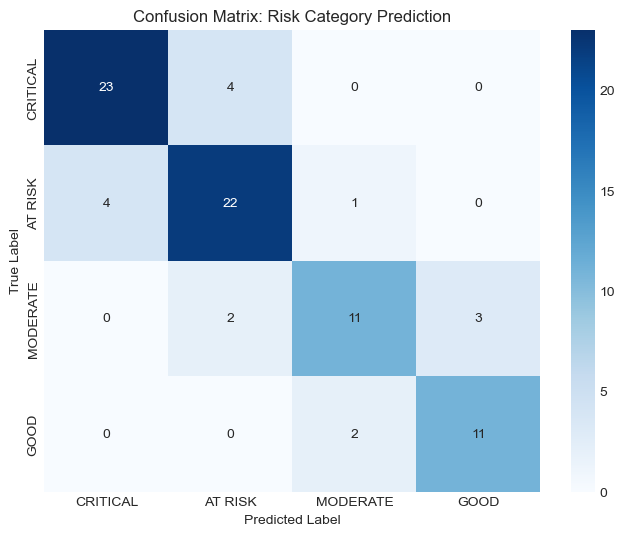

In [7]:
#Classification

print("CLASSIFICATION (District Risk Categories)")

# Create target labels using quartiles of the composite health score
class_df = df.dropna(subset=['composite_health_score']).copy()

# FIX: Use rank(method='first') to handle duplicate scores at quartile boundaries
class_df['risk_category'] = pd.qcut(
    class_df['composite_health_score'].rank(method='first'), 
    q=4, 
    labels=['CRITICAL', 'AT RISK', 'MODERATE', 'GOOD']
)

# Use the same features as before, plus a few nutrition indicators
class_features = features + ['anaemia_children', 'child_wasting']
class_df = class_df.dropna(subset=class_features)

X_cls = class_df[class_features]
y_cls = class_df['risk_category']

# Preprocessing
X_cls_imputed = imputer.fit_transform(X_cls)
X_cls_scaled = scaler.fit_transform(X_cls_imputed)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cls_scaled, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

# Train Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_clf.fit(X_train_c, y_train_c)

y_pred_c = rf_clf.predict(X_test_c)

print("Classification Report:\n", classification_report(y_test_c, y_pred_c))

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_c, y_pred_c, labels=['CRITICAL', 'AT RISK', 'MODERATE', 'GOOD'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['CRITICAL', 'AT RISK', 'MODERATE', 'GOOD'],
            yticklabels=['CRITICAL', 'AT RISK', 'MODERATE', 'GOOD'])
plt.title('Confusion Matrix: Risk Category Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

CLUSTERING (Unsupervised District Profiles)
Explained variance by 2 PCA components: 0.60


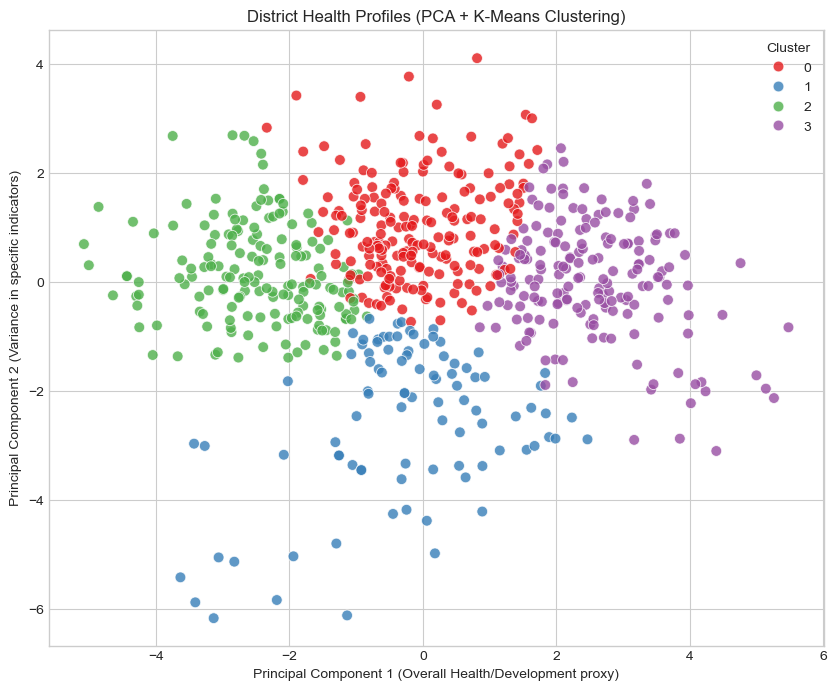


Average Indicator Values per Cluster:


,child_stunting,child_wasting,anaemia_children,anaemia_all_women,institutional_births,full_vaccination,hh_improved_sanitation,hh_clean_fuel,women_10yr_schooling,anc_4plus_visits,csection_rate
Cluster,,,,,,,,,,,
0,33.1,20.5,72.3,61.8,93.2,82.8,70.7,50.1,36.6,68.1,21.5
1,32.7,14.6,51.2,40.6,75.9,71.1,80.9,45.5,41.7,44.1,12.1
2,42.0,21.3,71.5,61.4,81.0,70.8,56.2,34.3,28.1,42.1,10.4
3,27.0,15.5,60.8,51.9,96.8,82.8,82.1,79.2,55.6,76.4,38.2


In [8]:
#District health profiles

print("CLUSTERING (Unsupervised District Profiles)")

# Select a broad range of key indicators
cluster_features = [
    'child_stunting', 'child_wasting', 'anaemia_children', 'anaemia_all_women',
    'institutional_births', 'full_vaccination', 'hh_improved_sanitation',
    'hh_clean_fuel', 'women_10yr_schooling', 'anc_4plus_visits', 'csection_rate'
]

clust_df = df.dropna(subset=cluster_features).copy()
X_clust = clust_df[cluster_features]

# Impute and Scale
X_clust_scaled = scaler.fit_transform(X_clust)

# Dimensionality Reduction (PCA) to visualize 11 dimensions in 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clust_scaled)

print(f"Explained variance by 2 PCA components: {sum(pca.explained_variance_ratio_):.2f}")

# Apply K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clust_df['Cluster'] = kmeans.fit_predict(X_clust_scaled)

# Visualize Clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clust_df['Cluster'], palette='Set1', s=60, alpha=0.8)
plt.title('District Health Profiles (PCA + K-Means Clustering)')
plt.xlabel('Principal Component 1 (Overall Health/Development proxy)')
plt.ylabel('Principal Component 2 (Variance in specific indicators)')
plt.legend(title='Cluster')
plt.show()

# Profile the clusters (what do they mean?)
cluster_profile = clust_df.groupby('Cluster')[cluster_features].mean().round(1)
print("\nAverage Indicator Values per Cluster:")
display(cluster_profile)

In [10]:

ml_district_profiles = class_df[['state', 'district_id', 'district_name', 'composite_health_score', 'risk_category']].copy()
ml_district_profiles['health_cluster'] = clust_df['Cluster']

# Map cluster numbers to descriptive names (adjust based on your actual cluster profiling)
cluster_names = {
    0: "Cluster A (High Risk/Poor Infra)",
    1: "Cluster B (Moderate/Developing)",
    2: "Cluster C (Good Infra/High Anaemia)",
    3: "Cluster D (Top Performers)"
}
ml_district_profiles['cluster_profile'] = ml_district_profiles['health_cluster'].map(cluster_names)

# Save 
#ml_district_profiles.to_csv(PROJECT_ROOT / "data" / "processed" / "ml_district_profiles.csv", index=False)
ml_district_profiles.to_sql('ml_district_profiles', engine, schema='nfhs', if_exists='replace', index=False)

# 2. Export XGBoost Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X_train_df.columns,
    'Importance': xgb_reg.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Making feature names readable for the dashboard
feature_name_mapping = {
    'women_10yr_schooling': 'Women with 10+ yrs Schooling',
    'hh_improved_sanitation': 'Improved Sanitation Access',
    'hh_clean_fuel': 'Clean Cooking Fuel Access',
    'institutional_births': 'Institutional Births',
    'anc_4plus_visits': '4+ Antenatal Care Visits',
    'women_married_before_18': 'Women Married Before 18',
    'hh_improved_water': 'Improved Drinking Water',
    'exclusive_breastfeeding': 'Exclusive Breastfeeding',
    'full_vaccination': 'Full Child Vaccination',
    'ifa_180_days': 'IFA Consumption (180 days)',
    'hh_health_insurance': 'Health Insurance Coverage'
}
feature_importance['Readable_Name'] = feature_importance['Feature'].map(feature_name_mapping)

#feature_importance.to_csv(PROJECT_ROOT / "data" / "processed" / "ml_feature_importance.csv", index=False)
feature_importance.to_sql('ml_feature_importance', engine, schema='nfhs', if_exists='replace', index=False)

print("ML metrics successfully exported for Power BI!")

ML metrics successfully exported for Power BI!
